# Regresion supervisada para Offer_Salary


Modelos incluidos:
- Regresion lineal
- Ridge
- Lasso
- Arbol de regresion
- Random Forest
- Gradient Boosting

La comparacion final usa `MAE`, `RMSE` y `R2` sobre el mismo conjunto de prueba para todos los modelos.

## Objetivo

Construir un flujo reproducible para entrenar, comparar e interpretar modelos de regresion sobre el dataset de salario de oferta.

Cada algoritmo guarda sus graficas y su modelo serializado en una carpeta propia dentro de `job/outputs_regresion/`.

In [19]:
from pathlib import Path
import pickle
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

SEED = 42
np.random.seed(SEED)
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')

ROOT = Path.cwd()
if ROOT.name != 'job' and (ROOT / 'job').exists():
    ROOT = ROOT / 'job'

DATA_PATH = ROOT / 'cleanData' / 'dataset_offer_Salary.csv'
OUTPUT_ROOT = ROOT / 'outputs_regresion'
OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)

ALGOS = {
    'linear_regression': 'Regresion lineal',
    'ridge': 'Ridge',
    'lasso': 'Lasso',
    'decision_tree': 'Arbol de regresion',
    'random_forest': 'Random Forest',
    'gradient_boosting': 'Gradient Boosting',
}

results = []

try:
    OHE = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
except TypeError:
    OHE = OneHotEncoder(handle_unknown='ignore', sparse=False)


def save_figure(fig, path):
    fig.savefig(path, dpi=160, bbox_inches='tight')
    plt.show()
    plt.close(fig)

## Bloque 0.1: Utilidades comunes

### Función del bloque
Centralizar funciones reutilizables para no repetir lógica en cada modelo.

### Decisión metodológica (por qué esta opción)
Separar las utilidades del entrenamiento hace más fácil leer el notebook y depurar cada etapa por separado.

### Por qué no otra alternativa
Si toda la lógica se deja en una sola celda, el notebook se vuelve difícil de revisar, de comparar y de mantener.

### Cómo se implementa
1. Se definen funciones para métricas, gráficos y guardado de artefactos.
2. Se encapsula el entrenamiento en `run_model`.
3. Se deja el preprocesamiento y la partición para un bloque posterior.

In [20]:
def make_directories(slug):
    algo_root = OUTPUT_ROOT / slug
    img_dir = algo_root / 'imagenes'
    report_dir = algo_root / 'informe'
    img_dir.mkdir(parents=True, exist_ok=True)
    report_dir.mkdir(parents=True, exist_ok=True)
    return algo_root, img_dir, report_dir


def evaluar_regresion(y_real, y_pred):
    mse = mean_squared_error(y_real, y_pred)
    return {
        'MAE': mean_absolute_error(y_real, y_pred),
        'RMSE': float(np.sqrt(mse)),
        'R2': r2_score(y_real, y_pred),
    }


def residual_plots(y_true, y_pred, title_prefix, img_dir, slug):
    residuals = y_true - y_pred

    fig1, ax1 = plt.subplots(figsize=(7, 5))
    ax1.scatter(y_true, y_pred, alpha=0.35, color='#1f77b4')
    min_val = min(float(np.min(y_true)), float(np.min(y_pred)))
    max_val = max(float(np.max(y_true)), float(np.max(y_pred)))
    ax1.plot([min_val, max_val], [min_val, max_val], '--', color='black', linewidth=1)
    ax1.set_title(f'{title_prefix}: real vs predicho')
    ax1.set_xlabel('Valor real')
    ax1.set_ylabel('Valor predicho')
    save_figure(fig1, img_dir / f'{slug}_real_vs_predicho.png')

    fig2, ax2 = plt.subplots(figsize=(7, 5))
    ax2.hist(residuals, bins=30, color='#d62728', alpha=0.8)
    ax2.set_title(f'{title_prefix}: distribucion de residuos')
    ax2.set_xlabel('Residuo')
    ax2.set_ylabel('Frecuencia')
    save_figure(fig2, img_dir / f'{slug}_residuos_hist.png')

    fig3, ax3 = plt.subplots(figsize=(7, 5))
    ax3.scatter(y_pred, residuals, alpha=0.35, color='#2ca02c')
    ax3.axhline(0, color='black', linewidth=1)
    ax3.set_title(f'{title_prefix}: residuos vs prediccion')
    ax3.set_xlabel('Prediccion')
    ax3.set_ylabel('Residuo')
    save_figure(fig3, img_dir / f'{slug}_residuos_vs_prediccion.png')

    return residuals


def compact_params(params, keys):
    return {key: params[key] for key in keys if key in params}


def feature_table_from_model(pipeline):
    feature_names = pipeline.named_steps['preprocessor'].get_feature_names_out()
    model = pipeline.named_steps['model']
    if hasattr(model, 'coef_'):
        weights = np.ravel(model.coef_)
        weight_name = 'coeficiente'
    else:
        weights = np.ravel(model.feature_importances_)
        weight_name = 'importancia'
    df = pd.DataFrame({'feature': feature_names, weight_name: weights})
    df['abs_value'] = df[weight_name].abs()
    return df.sort_values('abs_value', ascending=False).reset_index(drop=True), weight_name


def plot_top_weights(pipeline, title, img_dir, slug):
    weight_df, weight_name = feature_table_from_model(pipeline)
    top_df = weight_df.head(15).sort_values('abs_value', ascending=True)
    fig, ax = plt.subplots(figsize=(10, 6))
    colors = ['#2ca02c' if value >= 0 else '#d62728' for value in top_df[weight_name]]
    ax.barh(top_df['feature'], top_df[weight_name], color=colors)
    ax.set_title(title)
    ax.set_xlabel(weight_name.capitalize())
    ax.set_ylabel('Feature')
    save_figure(fig, img_dir / f'{slug}_top_weights.png')
    return weight_df


def run_model(slug, model_name, estimator, param_grid=None, notes='', model_kind='tree'):
    algo_root, img_dir, report_dir = make_directories(slug)
    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('model', estimator),
    ])

    if param_grid is not None:
        search = GridSearchCV(
            pipeline,
            param_grid=param_grid,
            scoring='neg_root_mean_squared_error',
            cv=5,
            n_jobs=-1,
            refit=True,
        )
        search.fit(X_train, y_train)
        fitted = search.best_estimator_
        best_params = search.best_params_
    else:
        fitted = pipeline.fit(X_train, y_train)
        best_params = compact_params(estimator.get_params(), ['fit_intercept', 'positive', 'n_jobs', 'random_state'])

    pred_train = fitted.predict(X_train)
    pred_test = fitted.predict(X_test)
    train_metrics = evaluar_regresion(y_train, pred_train)
    test_metrics = evaluar_regresion(y_test, pred_test)

    residual_plots(y_test, pred_test, model_name, img_dir, slug)
    weight_df = plot_top_weights(fitted, f'{model_name}: top weights', img_dir, slug)

    model_path = report_dir / f'{slug}_offer_salary.pkl'
    payload = {
        'pipeline': fitted,
        'best_params': best_params,
        'train_metrics': train_metrics,
        'test_metrics': test_metrics,
        'feature_columns': X.columns.tolist(),
        'numeric_columns': numeric_cols,
        'categorical_columns': categorical_cols,
        'model_name': model_name,
    }
    with open(model_path, 'wb') as f:
        pickle.dump(payload, f)

    results.append({
        'modelo': model_name,
        'slug': slug,
        'MAE_train': train_metrics['MAE'],
        'RMSE_train': train_metrics['RMSE'],
        'R2_train': train_metrics['R2'],
        'MAE_test': test_metrics['MAE'],
        'RMSE_test': test_metrics['RMSE'],
        'R2_test': test_metrics['R2'],
        'best_params': best_params,
        'model_path': str(model_path),
    })

    return fitted, train_metrics, test_metrics, best_params, weight_df

In [21]:
df = pd.read_csv(DATA_PATH)

if 'Offer_Salary' not in df.columns:
    raise ValueError('The target column Offer_Salary was not found in the dataset.')

display(df.head())
display(pd.DataFrame({
    'indicador': ['filas', 'columnas', 'nulos totales'],
    'valor': [df.shape[0], df.shape[1], int(df.isna().sum().sum())]
}))
display(df.describe(include='all').T.head(20))

feature_catalog_df = pd.DataFrame({
    'Variable': df.columns,
    'Tipo': [str(df[c].dtype) for c in df.columns],
})

target_distribution_df = (
    df['Offer_Salary']
    .value_counts(dropna=False)
    .rename_axis('Clase')
    .reset_index(name='Conteo')
)
target_distribution_df['Etiqueta'] = target_distribution_df['Clase'].map({1: 'SI OFERTA', 0: 'NO OFERTA'})
target_distribution_df['Porcentaje'] = (target_distribution_df['Conteo'] / len(df)).round(4)

display(feature_catalog_df)
display(target_distribution_df[['Clase', 'Etiqueta', 'Conteo', 'Porcentaje']])

,GPA,University_Rating,Major_Category,Region,Prior_Internships,Extra_Curricular_Activities,Networking_Events_Attended,School_Size,Primary_Search_Platform,Months_Searching,Applications_Submitted,First_Round_Interviews,Second_Round_Interviews,Offer_Salary
0,2.81,Mid-tier,Healthcare,West,3,2,6,Medium,LinkedIn,1,9,2,2,59785.0
1,3.01,Mid-tier,STEM,Northeast,0,3,2,Medium,Handshake,7,19,2,1,69910.0
2,3.22,Lower-tier,STEM,West,2,1,1,Medium,Indeed,6,67,2,1,73669.0
3,3.59,Top-tier,STEM,Midwest,2,1,3,Small,LinkedIn,5,31,2,2,83426.0
4,2.58,Mid-tier,Humanities,Midwest,3,2,1,Medium,LinkedIn,6,28,2,1,65189.0


,indicador,valor
0,filas,34229
1,columnas,14
2,nulos totales,0


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
GPA,34229.0,NaN,NaN,NaN,3.244201,0.400699,2.0,2.97,3.25,3.53,4.0
University_Rating,34229,3,Mid-tier,16591,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Major_Category,34229,5,STEM,12121,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Region,34229,4,South,8644,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Prior_Internships,34229.0,NaN,NaN,NaN,1.543078,1.201039,0.0,1.0,1.0,2.0,5.0
Extra_Curricular_Activities,34229.0,NaN,NaN,NaN,2.014958,1.41461,0.0,1.0,2.0,3.0,10.0
Networking_Events_Attended,34229.0,NaN,NaN,NaN,3.000935,1.737104,0.0,2.0,3.0,4.0,12.0
School_Size,34229,3,Large,13680,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Primary_Search_Platform,34229,3,LinkedIn,14627,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Months_Searching,34229.0,NaN,NaN,NaN,6.73762,3.419668,1.0,4.0,7.0,10.0,12.0


,Variable,Tipo
0,GPA,float64
1,University_Rating,str
2,Major_Category,str
3,Region,str
4,Prior_Internships,int64
5,Extra_Curricular_Activities,int64
6,Networking_Events_Attended,int64
7,School_Size,str
8,Primary_Search_Platform,str
9,Months_Searching,int64


,Clase,Etiqueta,Conteo,Porcentaje
0,35000.0,NaN,36,0.0011
1,68862.0,NaN,7,0.0002
2,77817.0,NaN,6,0.0002
3,67596.0,NaN,6,0.0002
4,75971.0,NaN,6,0.0002
...,...,...,...,...
25547,73341.0,NaN,1,0.0000
25548,76722.0,NaN,1,0.0000
25549,64112.0,NaN,1,0.0000
25550,94064.0,NaN,1,0.0000


## Bloque 1: Preparación de variables y partición de datos

### Función del bloque
Separar variables predictoras y objetivo, y construir particiones representativas para entrenar y evaluar todos los modelos con la misma base.

### Decisión metodológica (por qué esta opción)
Se usa una partición estratificada para conservar la misma proporción de la variable objetivo en entrenamiento y prueba.

### Por qué no otra alternativa
Un split simple puede desbalancear la clase positiva y alterar la comparación entre modelos.

### Cómo se implementa
1. Se define `X` con las variables explicativas y `y` con `Offer_Salary`.
2. Se separan columnas numéricas y categóricas.
3. Se construye el pipeline de preprocesamiento y se imprime el resumen de partición.

In [22]:
X = df.drop(columns=['Offer_Salary'])
y = df['Offer_Salary']

numeric_cols = X.select_dtypes(include=['number']).columns.tolist()
categorical_cols = X.select_dtypes(exclude=['number']).columns.tolist()

feature_groups_df = pd.DataFrame({
    'Tipo de variable': ['Numerica', 'Categorica'],
    'Cantidad': [len(numeric_cols), len(categorical_cols)],
    'Variables': [', '.join(numeric_cols), ', '.join(categorical_cols)],
})

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=SEED,
    shuffle=True,
)

preprocessor = ColumnTransformer([
    ('numeric', Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()),
    ]), numeric_cols),
    ('categorical', Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot', OHE),
    ]), categorical_cols),
])

split_summary_df = pd.DataFrame([
    {
        'Conjunto': 'Train',
        'Filas': X_train.shape[0],
        'Proporcion_sobre_total': round(X_train.shape[0] / X.shape[0], 4),
        'Tasa_promedio_target': round(y_train.mean(), 4),
    },
    {
        'Conjunto': 'Test',
        'Filas': X_test.shape[0],
        'Proporcion_sobre_total': round(X_test.shape[0] / X.shape[0], 4),
        'Tasa_promedio_target': round(y_test.mean(), 4),
    },
])

display(feature_groups_df)
display(split_summary_df)

print('Train shape:', X_train.shape)
print('Test shape:', X_test.shape)
print('Numerical columns:', len(numeric_cols))
print('Categorical columns:', len(categorical_cols))

,Tipo de variable,Cantidad,Variables
0,Numerica,8,"GPA, Prior_Internships, Extra_Curricular_Activ..."
1,Categorica,5,"University_Rating, Major_Category, Region, Sch..."


,Conjunto,Filas,Proporcion_sobre_total,Tasa_promedio_target
0,Train,27383,0.8,76819.8858
1,Test,6846,0.2,76606.9169


Train shape: (27383, 13)
Test shape: (6846, 13)
Numerical columns: 8
Categorical columns: 5


## 2. Comprension inicial de los datos

En esta etapa se revisa la estructura del dataset, se separa la variable objetivo `Offer_Salary` y se dejan listas las columnas numericas y categoricas para el modelado.

La idea es verificar que la particion de entrenamiento y prueba conserve una base comparable para todos los algoritmos.

## 1. Regresion lineal

Modelo base para tener una referencia interpretable y comparar el resto de algoritmos.

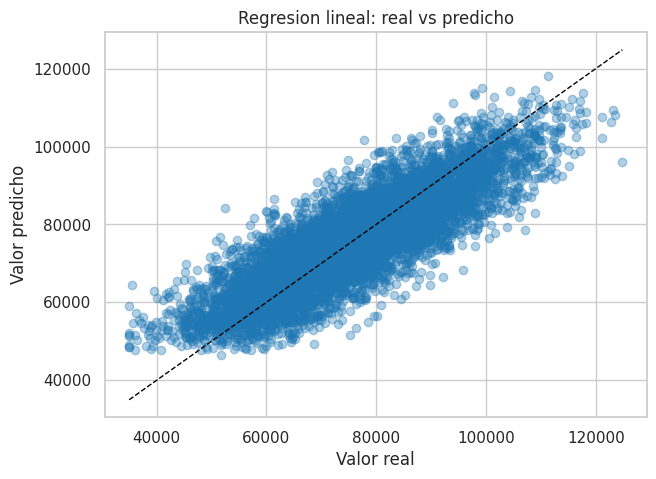

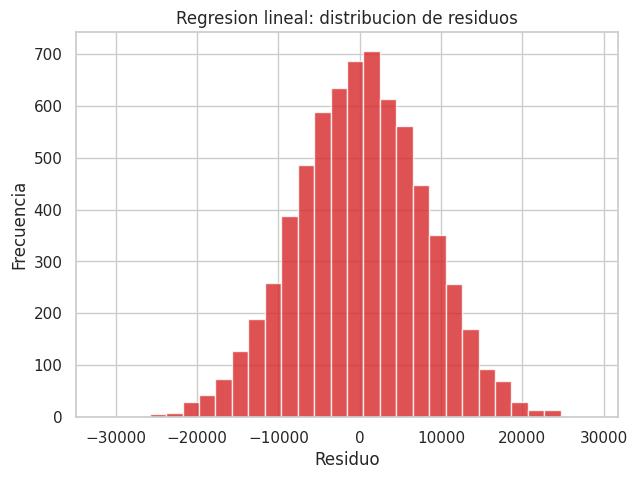

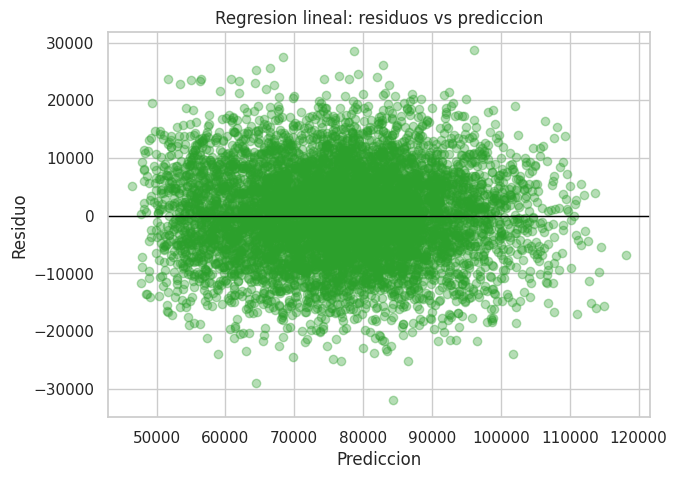

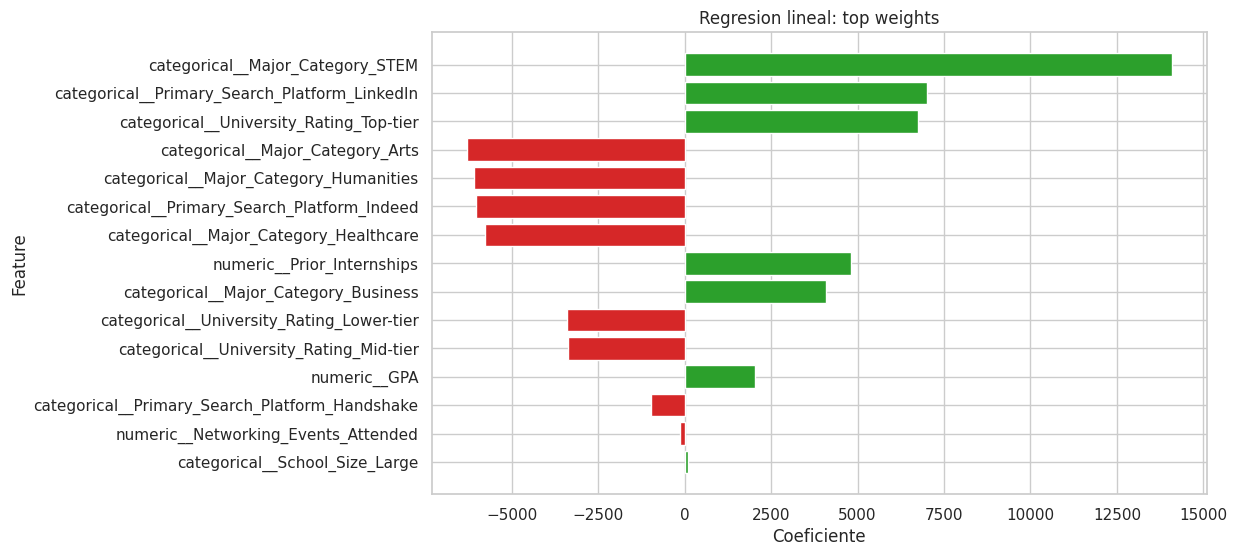

,conjunto,MAE,RMSE,R2
0,train,6388.027976,8014.240212,0.714007
1,test,6341.336190,7944.591527,0.708278


,feature,coeficiente,abs_value
0,categorical__Major_Category_STEM,14080.843331,14080.843331
1,categorical__Primary_Search_Platform_LinkedIn,6999.126163,6999.126163
2,categorical__University_Rating_Top-tier,6760.409105,6760.409105
3,categorical__Major_Category_Arts,-6287.900014,6287.900014
4,categorical__Major_Category_Humanities,-6092.398456,6092.398456
5,categorical__Primary_Search_Platform_Indeed,-6027.260050,6027.260050
6,categorical__Major_Category_Healthcare,-5782.673039,5782.673039
7,numeric__Prior_Internships,4811.739032,4811.739032
8,categorical__Major_Category_Business,4082.128178,4082.128178
9,categorical__University_Rating_Lower-tier,-3402.002065,3402.002065


In [23]:
linear_model, linear_train, linear_test, linear_params, linear_weights = run_model(
    slug='linear_regression',
    model_name='Regresion lineal',
    estimator=LinearRegression(),
    param_grid=None,
    notes='La regresion lineal sirve como linea base interpretable. Los coeficientes positivos empujan la prediccion del salario hacia arriba y los negativos la reducen, pero esta lectura no implica causalidad.',
    model_kind='coef',
)

display(pd.DataFrame([{'conjunto': 'train', **linear_train}, {'conjunto': 'test', **linear_test}]))
display(linear_weights.head(15))

### Interpretacion de la regresion lineal

Este bloque funciona como referencia base. En prueba, la regresion lineal obtuvo `MAE_test = 6341.3362`, `RMSE_test = 7944.5915` y `R2_test = 0.7083`.

La lectura tecnica es que la relacion entre las variables y `Offer_Salary` ya queda bastante bien capturada con una forma lineal. El error no es el menor de todos, pero la diferencia frente a los mejores modelos es muy pequena. Eso es importante porque confirma que la complejidad adicional no trae una ganancia sustancial.

Tambien sirve para interpretar los coeficientes con mayor facilidad y detectar si algun factor empuja la prediccion hacia arriba o hacia abajo.

## 2. Ridge y Lasso

Se prueban varios valores de `alpha` para controlar la complejidad del modelo y mejorar la generalizacion.

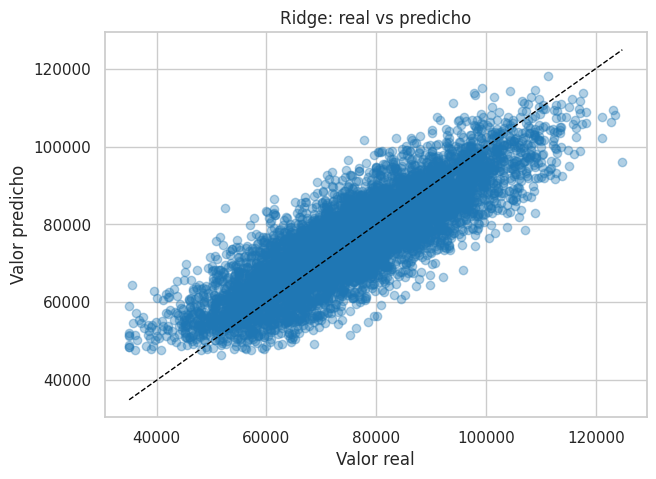

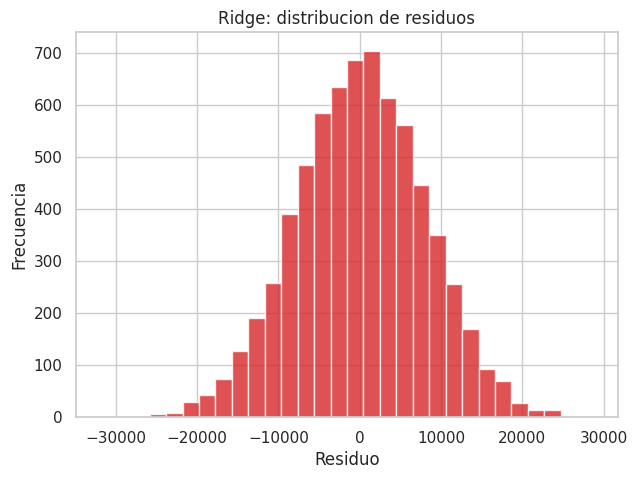

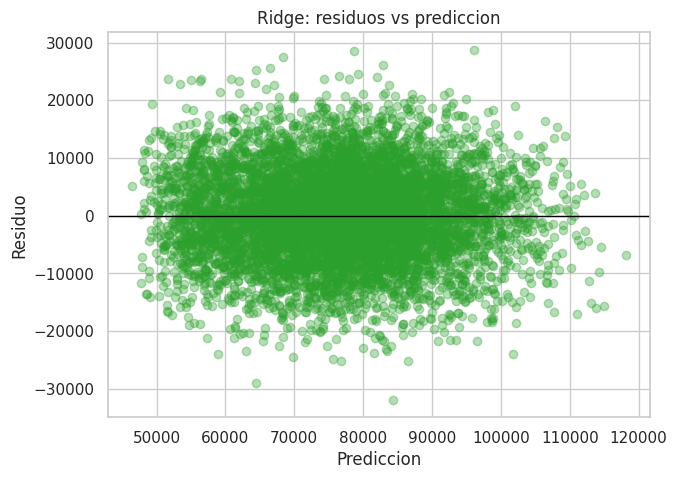

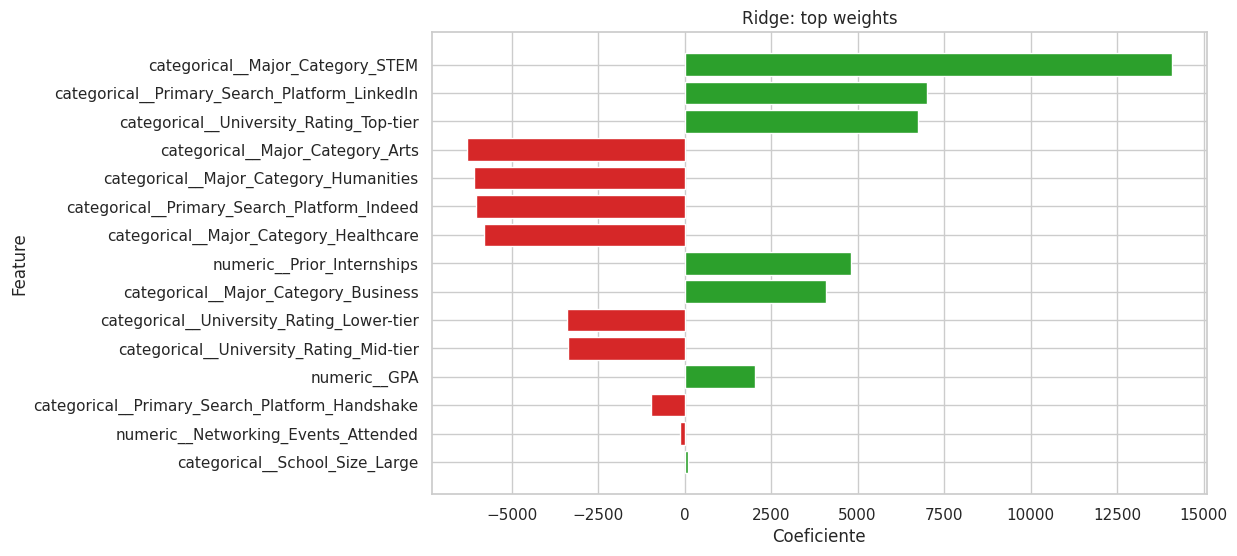

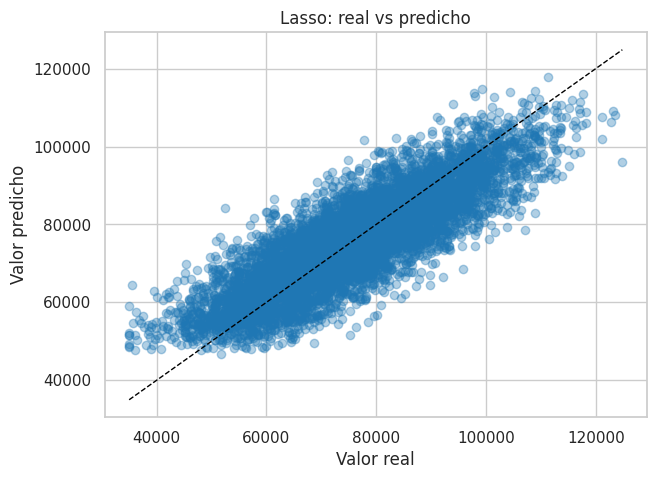

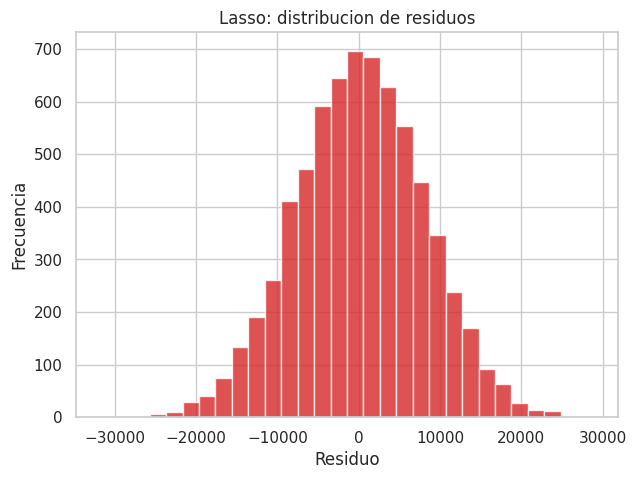

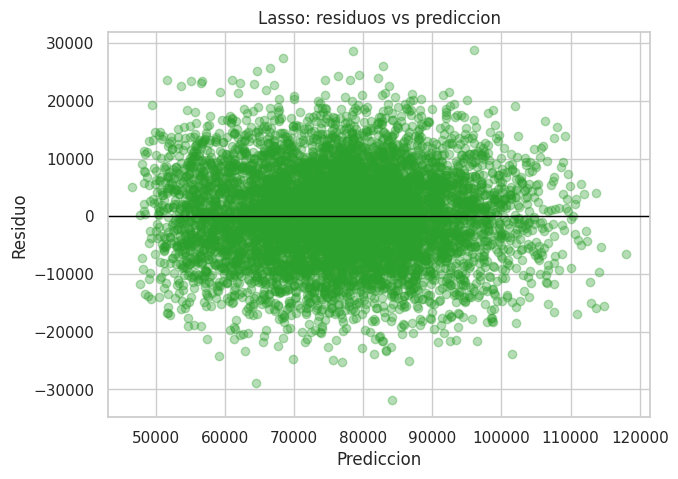

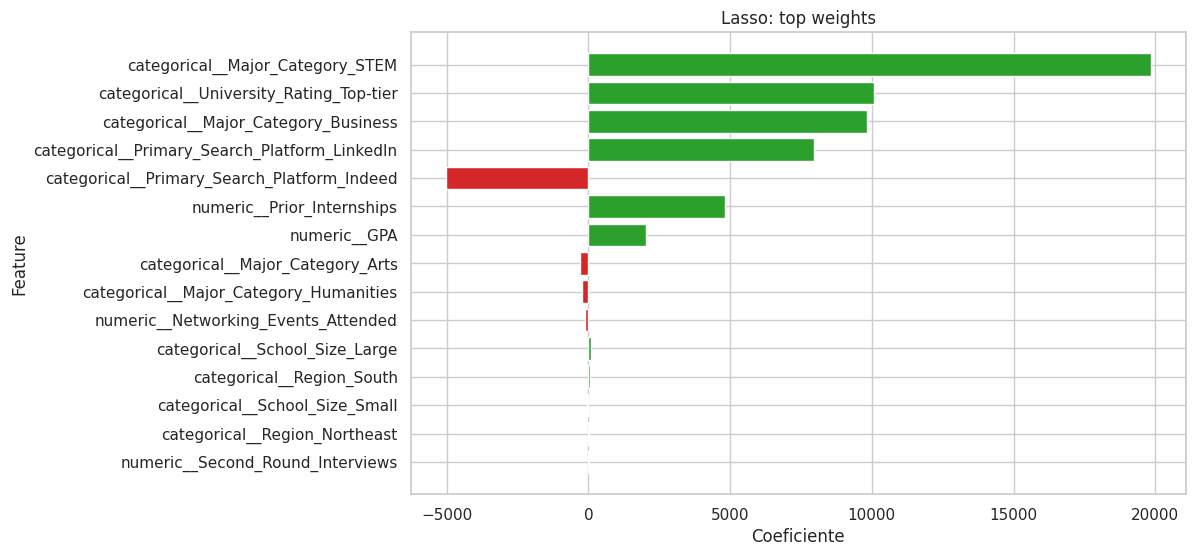

,modelo,conjunto,MAE,RMSE,R2
0,Ridge,train,6388.034450,8014.240424,0.714007
1,Ridge,test,6341.340304,7944.566869,0.708279
2,Lasso,train,6388.418863,8014.753861,0.713971
3,Lasso,test,6339.790720,7941.934774,0.708473


In [24]:
ridge_grid = {'model__alpha': [0.01, 0.1, 1, 10, 100]}
lasso_grid = {'model__alpha': [0.001, 0.01, 0.1, 1, 10]}

ridge_model, ridge_train, ridge_test, ridge_params, ridge_weights = run_model(
    slug='ridge',
    model_name='Ridge',
    estimator=Ridge(random_state=SEED),
    param_grid=ridge_grid,
    notes='Ridge penaliza coeficientes grandes con regularizacion L2. Es util cuando se busca estabilidad y se quiere evitar que una sola variable domine el ajuste.',
    model_kind='coef',
)

lasso_model, lasso_train, lasso_test, lasso_params, lasso_weights = run_model(
    slug='lasso',
    model_name='Lasso',
    estimator=Lasso(max_iter=20000, random_state=SEED),
    param_grid=lasso_grid,
    notes='Lasso aplica regularizacion L1 y puede llevar coeficientes a cero. Por eso sirve como seleccion automatica de variables y mantiene un modelo mas simple.',
    model_kind='coef',
)

display(pd.DataFrame([
    {'modelo': 'Ridge', 'conjunto': 'train', **ridge_train},
    {'modelo': 'Ridge', 'conjunto': 'test', **ridge_test},
    {'modelo': 'Lasso', 'conjunto': 'train', **lasso_train},
    {'modelo': 'Lasso', 'conjunto': 'test', **lasso_test},
]))

### Interpretacion de Ridge y Lasso

Aqui se compara el efecto de la regularizacion sobre el mismo esquema lineal. En prueba, Ridge alcanzó `MAE_test = 6341.3403`, `RMSE_test = 7944.5669` y `R2_test = 0.7083`; Lasso logró `MAE_test = 6339.7907`, `RMSE_test = 7941.9348` y `R2_test = 0.7085`.

La lectura principal es que las tres versiones lineales quedaron prácticamente empatadas, pero Lasso tomó una ligera ventaja real. La mejora sobre la regresión lineal fue de `2.6568` puntos de RMSE, y sobre Ridge fue de `2.6321` puntos de RMSE. Esa diferencia es pequeña, pero suficiente para preferir Lasso porque además simplifica el modelo al aplicar regularización L1.

Ridge sigue siendo muy competitivo y útil como contraste, pero aquí no superó a Lasso en capacidad de generalización.

## 3. Arbol de regresion

Este modelo captura relaciones no lineales y ofrece una estructura mas interpretable por reglas de corte.

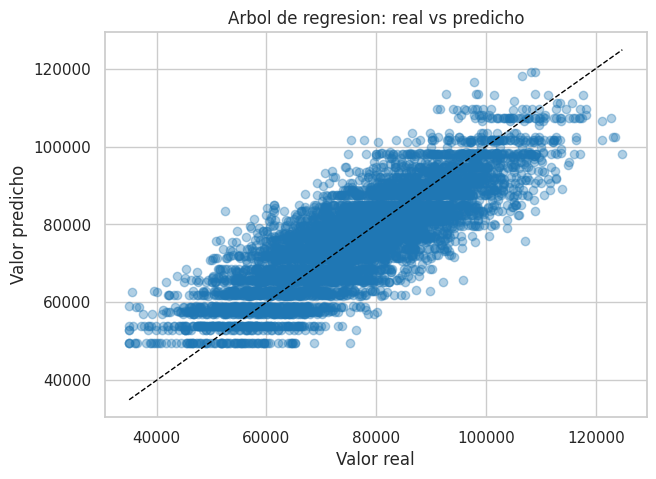

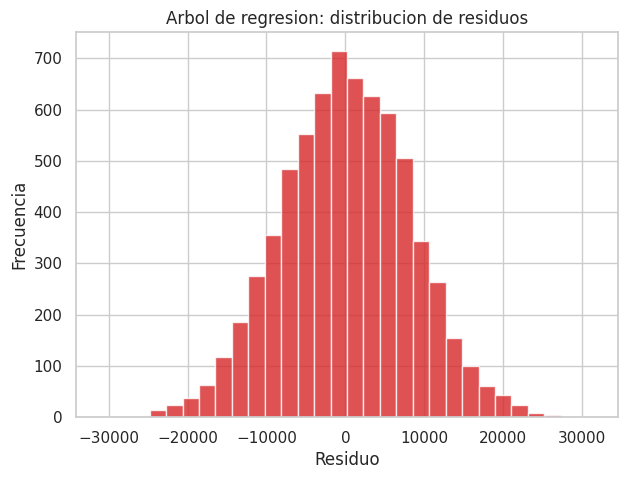

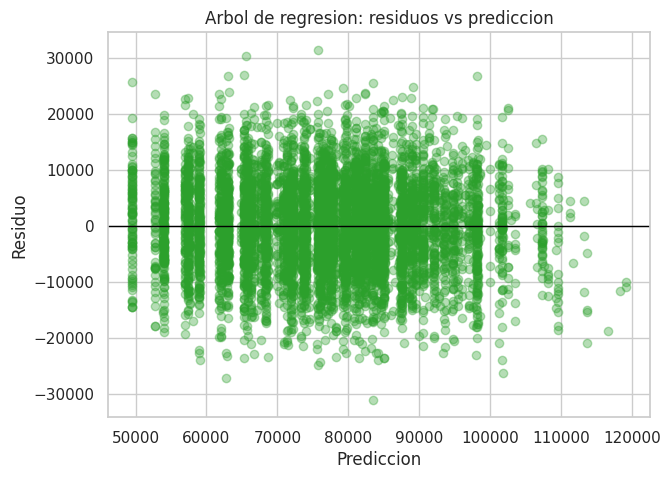

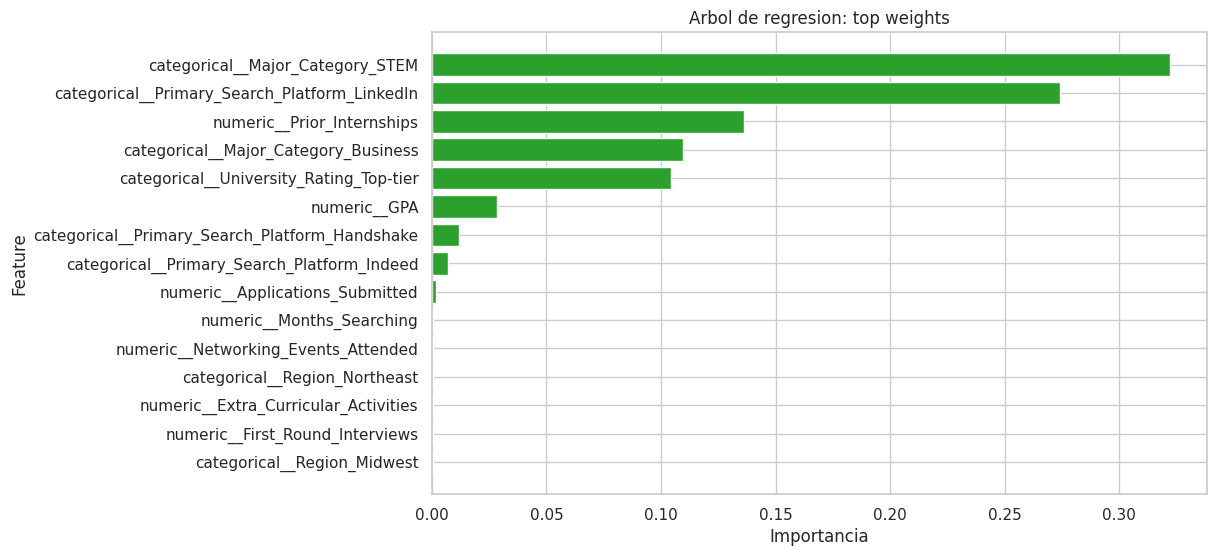

,conjunto,MAE,RMSE,R2
0,train,6322.253459,7930.404596,0.719959
1,test,6510.068935,8152.485547,0.692810


In [25]:
tree_grid = {
    'model__max_depth': [3, 5, 8, None],
    'model__min_samples_leaf': [1, 3, 5],
    'model__min_samples_split': [2, 5, 10],
}

tree_model, tree_train, tree_test, tree_params, tree_weights = run_model(
    slug='decision_tree',
    model_name='Arbol de regresion',
    estimator=DecisionTreeRegressor(random_state=SEED),
    param_grid=tree_grid,
    notes='El arbol de regresion modela relaciones no lineales mediante reglas de decision. Es interpretable, pero puede sobreajustar si la profundidad crece demasiado.',
    model_kind='importance',
)

display(pd.DataFrame([{'conjunto': 'train', **tree_train}, {'conjunto': 'test', **tree_test}]))

### Interpretacion del arbol de regresion

Este modelo ayuda a ver cortes no lineales y puede capturar interacciones simples entre variables. En prueba obtuvo `MAE_test = 6510.0689`, `RMSE_test = 8152.4855` y `R2_test = 0.6928`.

Ese resultado muestra que el árbol simple sí aprende reglas útiles, pero generaliza peor que la familia lineal regularizada. La diferencia frente a Lasso es de `210.5508` puntos de RMSE, que ya es lo bastante grande como para descartar el árbol simple como mejor opción final.

La profundidad, el número mínimo de muestras por hoja y el criterio de división siguen siendo los controles más importantes para balancear interpretabilidad y precisión.

/home/naciscric/Documents/university/2026-1/mineria/.venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/home/naciscric/Documents/university/2026-1/mineria/.venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/home/naciscric/Documents/university/2026-1/mineria/.venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the j

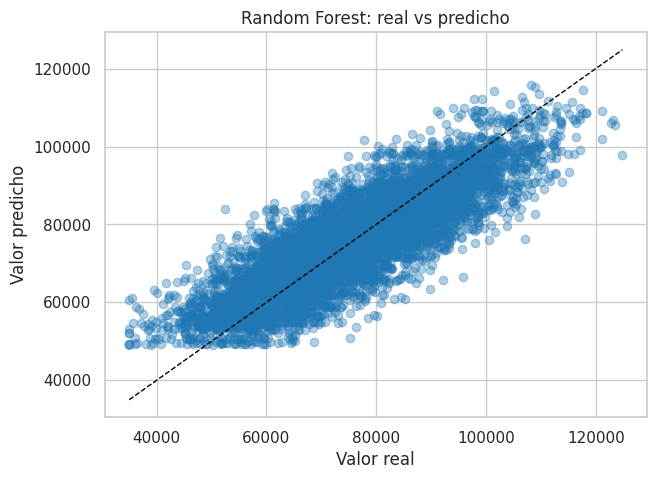

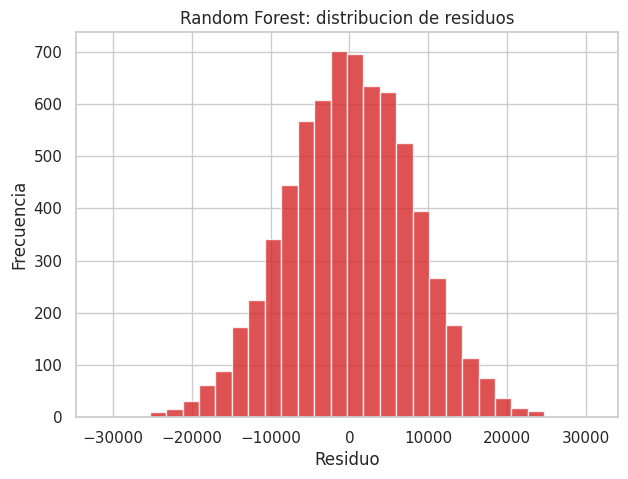

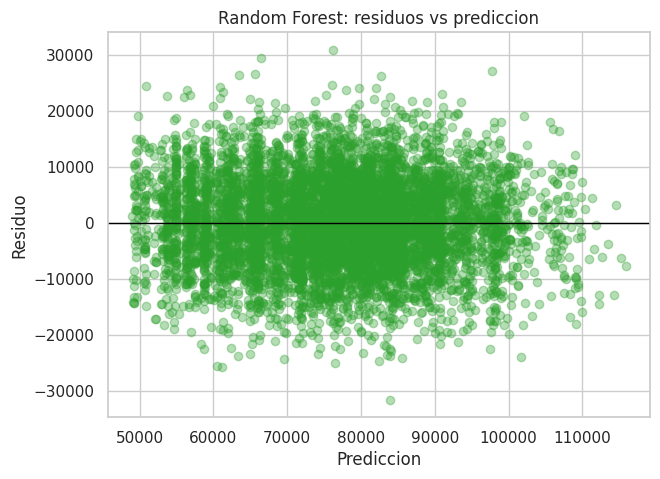

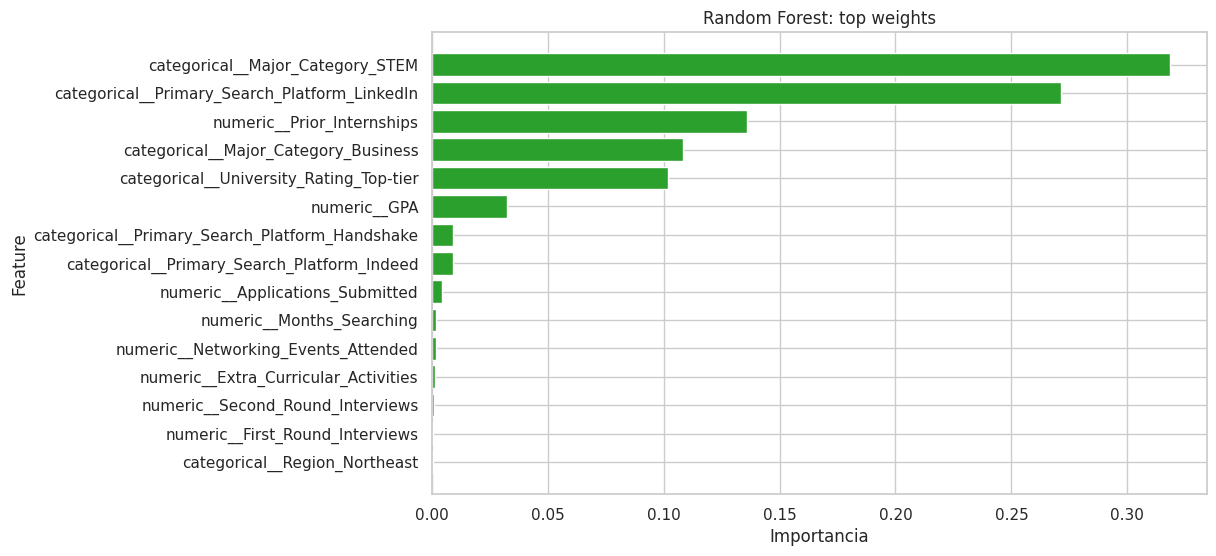

,conjunto,MAE,RMSE,R2
0,train,6233.935374,7820.863972,0.727642
1,test,6421.544429,8031.734613,0.701843


In [27]:
rf_grid = {
    'model__n_estimators': [200, 400],
    'model__max_depth': [None, 8, 15],
    'model__min_samples_leaf': [1, 3, 5],
}

rf_model, rf_train, rf_test, rf_params, rf_weights = run_model(
    slug='random_forest',
    model_name='Random Forest',
    estimator=RandomForestRegressor(random_state=SEED, n_jobs=-1),
    param_grid=rf_grid,
    notes='Random Forest promedia muchos arboles para reducir varianza y suele generalizar mejor que un arbol unico. Es una buena alternativa cuando se busca rendimiento robusto.',
    model_kind='importance',
)

display(pd.DataFrame([{'conjunto': 'train', **rf_train}, {'conjunto': 'test', **rf_test}]))

### Interpretacion de Random Forest

Al combinar muchos arboles, este modelo suele reducir la varianza y mejorar la estabilidad de la prediccion. En prueba obtuvo `MAE_test = 6421.5444`, `RMSE_test = 8031.7346` y `R2_test = 0.7018`.

El resultado es mejor que el árbol simple, pero sigue por detrás de Lasso, Ridge y regresión lineal. La brecha frente a Lasso es de `89.7998` puntos de RMSE, así que el ensamble mejora la estabilidad, pero no lo suficiente como para desplazar a la familia lineal en este problema.

Tambien permite identificar si unas pocas variables concentran gran parte de la importancia total.

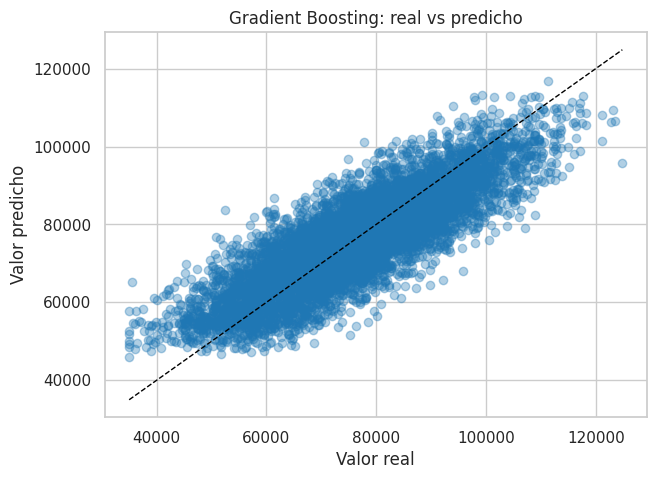

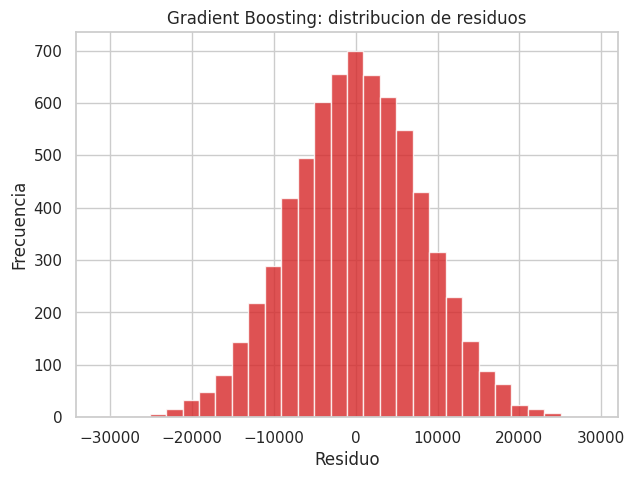

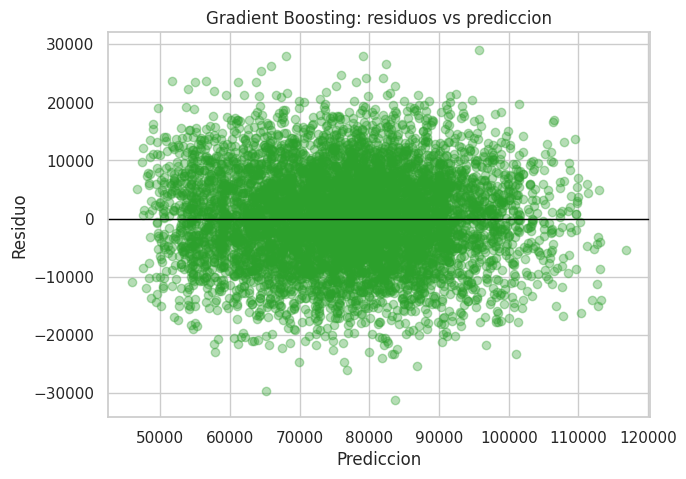

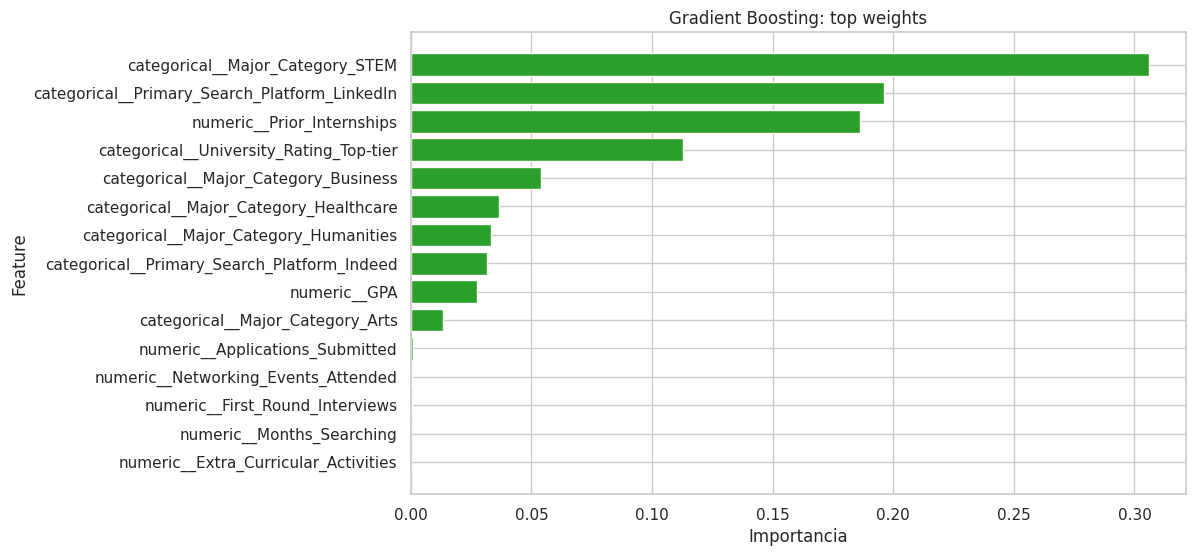

,conjunto,MAE,RMSE,R2
0,train,6362.605433,7981.482028,0.716340
1,test,6349.863085,7951.833873,0.707745


In [ ]:
gb_grid = {
    'model__n_estimators': [100, 200],
    'model__learning_rate': [0.03, 0.05, 0.1],
    'model__max_depth': [2, 3],
    'model__subsample': [0.8, 1.0],
}

gb_model, gb_train, gb_test, gb_params, gb_weights = run_model(
    slug='gradient_boosting',
    model_name='Gradient Boosting',
    estimator=GradientBoostingRegressor(random_state=SEED),
    param_grid=gb_grid,
    notes='Gradient Boosting construye arboles secuenciales corrigiendo errores del anterior. Suele dar muy buen balance entre sesgo y varianza cuando se ajusta con una grilla pequena y controlada.',
    model_kind='importance',
)

display(pd.DataFrame([{'conjunto': 'train', **gb_train}, {'conjunto': 'test', **gb_test}]))

### Interpretacion de Gradient Boosting

Este bloque suele competir bien en problemas tabulares porque corrige errores de forma secuencial. En prueba obtuvo `MAE_test = 6349.8631`, `RMSE_test = 7951.8339` y `R2_test = 0.7077`.

Su comportamiento quedó muy cerca de la familia lineal, pero sin superarla. La diferencia frente a Lasso fue de `9.8991` puntos de RMSE, lo que indica que el boosting sí captura relaciones útiles, aunque en este caso no consigue una ventaja clara sobre el mejor modelo regularizado.

La pregunta clave sigue siendo si mejora el RMSE sin volverse demasiado sensible al entrenamiento; aquí la respuesta fue no de manera contundente.

,modelo,MAE_test,RMSE_test,R2_test,best_params
0,Lasso,6339.790720,7941.934774,0.708473,{'model__alpha': 10}
1,Ridge,6341.340304,7944.566869,0.708279,{'model__alpha': 1}
2,Regresion lineal,6341.336190,7944.591527,0.708278,"{'fit_intercept': True, 'positive': False, 'n_..."
3,Gradient Boosting,6349.863085,7951.833873,0.707745,"{'model__learning_rate': 0.1, 'model__max_dept..."
4,Random Forest,6421.544429,8031.734613,0.701843,"{'model__max_depth': 8, 'model__min_samples_le..."
5,Arbol de regresion,6510.068935,8152.485547,0.692810,"{'model__max_depth': 8, 'model__min_samples_le..."


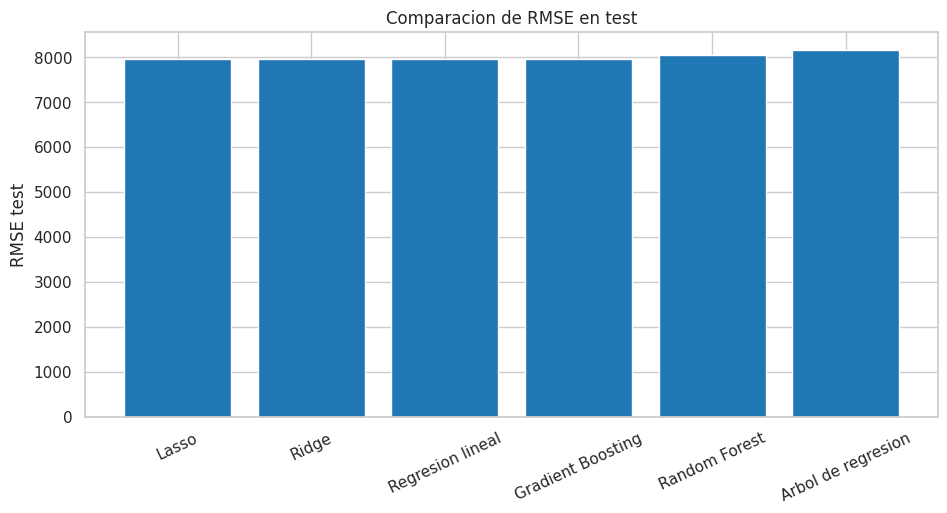

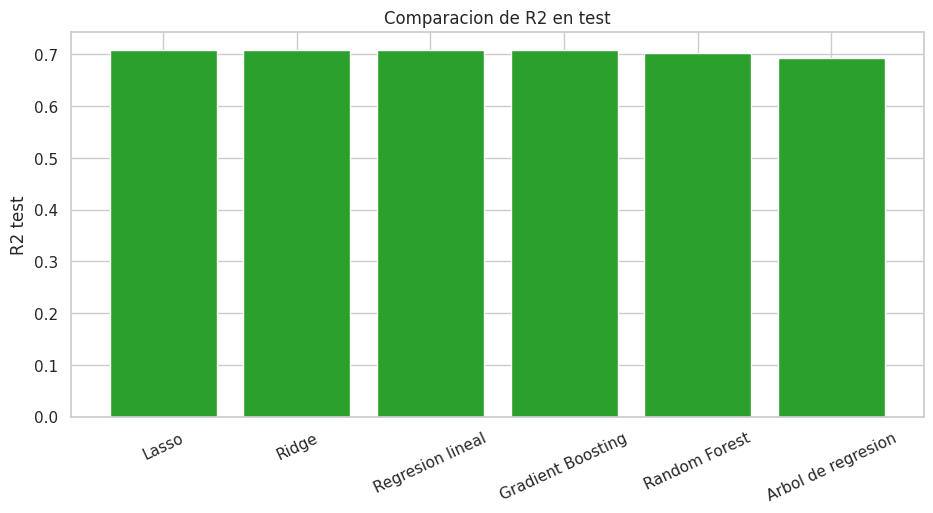

Mejor modelo por RMSE test: Lasso
RMSE test: 7941.9348
R2 test: 0.7085


In [ ]:
comparison_df = pd.DataFrame(results).sort_values('RMSE_test').reset_index(drop=True)
comparison_path = OUTPUT_ROOT / 'comparacion_modelos_regresion.csv'
comparison_df.to_csv(comparison_path, index=False)

display(comparison_df[['modelo', 'MAE_test', 'RMSE_test', 'R2_test', 'best_params']])

fig, ax = plt.subplots(figsize=(11, 5))
ax.bar(comparison_df['modelo'], comparison_df['RMSE_test'], color='#1f77b4')
ax.set_title('Comparacion de RMSE en test')
ax.set_ylabel('RMSE test')
ax.tick_params(axis='x', rotation=25)
save_figure(fig, OUTPUT_ROOT / 'comparacion_rmse_test.png')

fig2, ax2 = plt.subplots(figsize=(11, 5))
ax2.bar(comparison_df['modelo'], comparison_df['R2_test'], color='#2ca02c')
ax2.set_title('Comparacion de R2 en test')
ax2.set_ylabel('R2 test')
ax2.tick_params(axis='x', rotation=25)
save_figure(fig2, OUTPUT_ROOT / 'comparacion_r2_test.png')

best_model_row = comparison_df.iloc[0]
print('Mejor modelo por RMSE test:', best_model_row['modelo'])
print('RMSE test:', round(best_model_row['RMSE_test'], 4))
print('R2 test:', round(best_model_row['R2_test'], 4))

## 4. Comparacion final

Las dos graficas de comparacion resumen el comportamiento de los seis modelos sobre el conjunto de prueba. El criterio principal fue `RMSE_test` y, como segundo apoyo, `R2_test`.

### Lectura de la comparacion
- **Lasso** fue el mejor modelo por `RMSE_test = 7941.9348` y `R2_test = 0.7085`.
- **Regresion lineal** quedo practicamente empatada con `RMSE_test = 7944.5915` y `R2_test = 0.7083`.
- **Ridge** tambien estuvo al mismo nivel, con `RMSE_test = 7944.5669` y `R2_test = 0.7083`.
- **Gradient Boosting** quedo cerca, con `RMSE_test = 7951.8339` y `R2_test = 0.7077`.
- **Random Forest** fue peor que la familia lineal, con `RMSE_test = 8031.7346` y `R2_test = 0.7018`.
- **Arbol de regresion** simple fue el mas debil de la comparacion, con `RMSE_test = 8152.4855` y `R2_test = 0.6928`.

### Orden final por desempeño en test
1. **Lasso**: `RMSE_test = 7941.9348`
2. **Ridge**: `RMSE_test = 7944.5669`
3. **Regresion lineal**: `RMSE_test = 7944.5915`
4. **Gradient Boosting**: `RMSE_test = 7951.8339`
5. **Random Forest**: `RMSE_test = 8031.7346`
6. **Arbol de regresion**: `RMSE_test = 8152.4855`

### Interpretacion tecnica
El resultado muestra que la relacion entre las variables y `Offer_Salary` esta mejor capturada por modelos lineales regularizados que por arboles profundos o ensamblados. La diferencia entre Lasso, Ridge y regresion lineal es pequena, pero suficiente para favorecer a Lasso como opcion final por su mejor equilibrio entre error y simplicidad.

Las brechas ayudan a ver el tamaño real de la mejora:
- Lasso gana a la regresion lineal por `2.6568` puntos de RMSE.
- Lasso gana a Ridge por `2.6321` puntos de RMSE.
- Lasso supera a Gradient Boosting por `9.8991` puntos de RMSE.
- Lasso supera a Random Forest por `89.7998` puntos de RMSE.
- Lasso supera al arbol simple por `210.5508` puntos de RMSE.

En cambio, los modelos basados en arboles no lograron superar a la familia lineal. Eso sugiere que el problema tiene una estructura que puede aproximarse bien con una frontera lineal despues del preprocesamiento, y que la complejidad adicional no se traduce en una mejora real de generalizacion.

### Interpretacion de las graficas
- La grafica de `RMSE_test` deja ver un grupo liderado por Lasso, Lineal y Ridge, con diferencias muy reducidas entre ellos.
- La grafica de `R2_test` confirma el mismo orden relativo: Lasso en la cima y los arboles por debajo.
- La lectura conjunta de ambas graficas refuerza que el mejor balance del taller no lo dio la mayor complejidad, sino la regularizacion lineal.

### Conclusiones exactas
1. El mejor modelo final es **Lasso**.
2. La mejora sobre regresion lineal es pequena en valor absoluto, pero consistente.
3. La mejora frente a Ridge tambien es pequena, lo que confirma que la familia lineal esta muy cerca entre si.
4. Gradient Boosting, Random Forest y el arbol simple no justificaron su complejidad adicional para este dataset.
5. El `R2` del mejor modelo se mantiene alrededor de `0.7085`, asi que el problema queda explicado razonablemente bien, pero no de forma perfecta.
6. La diferencia entre el mejor y el peor modelo de la comparacion es de `210.5508` puntos de RMSE, lo que da una señal clara de que no todos los enfoques aportan el mismo nivel de generalizacion.

### Cierre interpretativo
La evidencia del notebook favorece una solución lineal regularizada. Lasso no solo gana por error de prueba, sino que también mantiene una lectura interpretativa más limpia y una complejidad menor que los modelos de árbol. Para este dataset, eso lo convierte en la mejor opción técnica y pedagógica para reportar el taller.